In [ ]:
!pip install rasterio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 18.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from tqdm import tqdm
from PIL import Image

import rasterio
from rasterio.errors import RasterioIOError
import re
from joblib import Parallel, delayed

from collections import defaultdict

import warnings
warnings.filterwarnings("ignore")


In [ ]:
path = "/content/drive/MyDrive/cotedivoire_cyber_updated/"

train_geo = gpd.read_file(path + "trainGeo.geojson")

train = pd.read_csv(path + 'TrainDataset.csv').dropna(subset=['tifPath'])
test = pd.read_csv(path + 'TestDataset.csv').dropna(subset=['tifPath'])
train['tifPath'] = train['tifPath'].apply(lambda x: f"{path}S2Images/train/" + x.split("/")[-1])
train['base_id'] = train['ID'].apply(lambda x: "_".join(x.split("_")[:2]))
test['tifPath'] = test['tifPath'].apply(lambda x: f"{path}S2Images/test/" + x.split("/")[-1])
print(train['tifPath'][0])
print(test['tifPath'][0])
sub = pd.read_csv(path + 'SampleSubmission.csv')
display(train.head(), train.shape, test.head(), test.shape, train_geo.head(), sub.head(), sub.shape)

/content/drive/MyDrive/cotedivoire_cyber_updated/S2Images/train/s2_Rubber_ID_h14T0B_2024_01.tif
/content/drive/MyDrive/cotedivoire_cyber_updated/S2Images/test/s2_Unknown_ID_731818_2024_01.tif


,ID,year,month,tifPath,Target,class,base_id
0,ID_h14T0B_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_h14T0B
1,ID_KbyKOr_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_KbyKOr
2,ID_t4Tmmn_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_t4Tmmn
3,ID_yipWoC_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_yipWoC
4,ID_XKiksa_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_XKiksa


(7433, 7)

,ID,year,month,tifPath
0,ID_731818_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...
1,ID_790093_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...
2,ID_931033_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...
3,ID_079024_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...
4,ID_691532_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...


(2201, 4)

,ID,year,Target,class,geometry
0,ID_h14T0B,2024,Rubber,3,"POLYGON ((-7.47662 4.79479, -7.47672 4.7947, -..."
1,ID_KbyKOr,2024,Rubber,3,"MULTIPOLYGON (((-7.11499 4.76768, -7.11471 4.7..."
2,ID_t4Tmmn,2024,Rubber,3,"MULTIPOLYGON (((-7.09768 4.90044, -7.09732 4.9..."
3,ID_yipWoC,2024,Rubber,3,"MULTIPOLYGON (((-7.11829 4.76918, -7.11714 4.7..."
4,ID_XKiksa,2024,Rubber,3,"POLYGON ((-7.51713 4.66244, -7.51711 4.66249, ..."


,ID,Target
0,ID_731818,NaN
1,ID_790093,NaN
2,ID_931033,NaN
3,ID_079024,NaN
4,ID_691532,NaN


(282, 2)

In [ ]:
train[(train['month'] == "Jan") & (train['base_id'] == 'ID_h14T0B')]


,ID,year,month,tifPath,Target,class,base_id
0,ID_h14T0B_Jan,2024,Jan,/content/drive/MyDrive/cotedivoire_cyber_updat...,Rubber,3,ID_h14T0B


In [ ]:
train.isnull().sum()

,0
ID,0
year,0
month,0
tifPath,0
Target,0
class,0
base_id,0


### Prepare the Test Data

In [ ]:
train.shape

(7433, 7)

In [ ]:
len(os.listdir("/content/drive/MyDrive/cotedivoire_cyber_updated/S2Images/train"))

7435

In [ ]:
train['tifPath'][0]

'/content/drive/MyDrive/cotedivoire_cyber_updated/S2Images/train/s2_Rubber_ID_h14T0B_2024_01.tif'

In [ ]:
image_path = "/content/drive/MyDrive/cotedivoire_cyber_updated/S2Images/train/s2_Rubber_ID_h14T0B_2024_01.tif"
with rasterio.open(image_path) as src:
  array = src.read().astype(np.float32)  # shape: (bands, height, width)
  print(array)

[[[2589. 2589. 2589. ... 2594. 2594. 2594.]
  [2589. 2589. 2589. ... 2594. 2594. 2594.]
  [2589. 2589. 2589. ... 2594. 2594. 2594.]
  ...
  [2580. 2580. 2580. ... 2566. 2566. 2566.]
  [2580. 2580. 2580. ... 2566. 2566. 2566.]
  [2580. 2580. 2580. ... 2566. 2566. 2566.]]

 [[2312. 2287. 2272. ... 2256. 2274. 2282.]
  [2309. 2289. 2277. ... 2279. 2316. 2321.]
  [2274. 2284. 2276. ... 2301. 2354. 2373.]
  ...
  [2273. 2281. 2271. ... 2249. 2248. 2239.]
  [2272. 2259. 2267. ... 2243. 2244. 2240.]
  [2284. 2257. 2265. ... 2242. 2253. 2230.]]

 [[2169. 2156. 2103. ... 2070. 2095. 2136.]
  [2149. 2131. 2102. ... 2122. 2132. 2162.]
  [2118. 2137. 2095. ... 2143. 2210. 2248.]
  ...
  [2128. 2113. 2108. ... 2076. 2067. 2064.]
  [2130. 2089. 2081. ... 2076. 2051. 2053.]
  [2114. 2095. 2089. ... 2064. 2070. 2052.]]

 ...

 [[1434. 1434. 1434. ... 1398. 1398. 1398.]
  [1434. 1434. 1434. ... 1398. 1398. 1398.]
  [1446. 1446. 1446. ... 1389. 1389. 1389.]
  ...
  [1403. 1403. 1403. ... 1379. 1379. 137

In [ ]:
print(array.shape)

(12, 51, 51)


In [ ]:
array = array.reshape(array.shape[0], -1)  # shape: (bands, pixels)
print(array.shape)

(12, 2601)


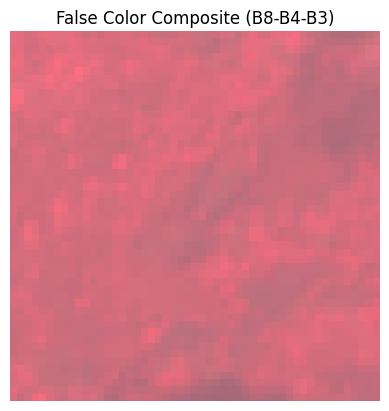

In [ ]:
with rasterio.open(image_path) as src:
  # Near-Infrared (B8), Red (B4), Green (B3)
  nir = src.read(8).astype(np.float32)
  red = src.read(4).astype(np.float32)
  green = src.read(3)

  false_color = np.stack([nir, red, green], axis=-1).astype(np.float32)
  false_color /= false_color.max()

  plt.imshow(false_color)
  plt.title("False Color Composite (B8-B4-B3)")
  plt.axis('off')
  plt.show()


In [ ]:
SENTINEL_2_BAND_NAMES = [
    "B1",  "B2",  "B3",  "B4",
    "B5",  "B6",  "B7",  "B8",
    "B8A", "B9", "B11", "B12"
]

def compute_aggregate_stats(tif_paths):
    band_arrays = []

    for path in tif_paths:
        try:
            with rasterio.open(path) as src:
                array = src.read().astype(np.float32)  # shape: (bands, height, width)
                array = array.reshape(array.shape[0], -1)  # shape: (bands, pixels)
                band_arrays.append(array)
        except (RasterioIOError, FileNotFoundError) as e:
            warnings.warn(f"Skipping file {path}: {e}")
            continue

    if not band_arrays:
        return None  # Return None if no valid images

    # Concatenate along pixel axis
    full_array = np.concatenate(band_arrays, axis=1)  # shape: (bands, total_pixels)

    band_stats = {}
    for i in range(full_array.shape[0]):
        band_data = full_array[i]
        band_data = band_data[~np.isnan(band_data)]
        band_name = SENTINEL_2_BAND_NAMES[i] if i < len(SENTINEL_2_BAND_NAMES) else f'B{i+1}'

        band_stats[f'{band_name}_mean'] = np.mean(band_data)
        band_stats[f'{band_name}_median'] = np.median(band_data)
        band_stats[f'{band_name}_min'] = np.min(band_data)
        band_stats[f'{band_name}_max'] = np.max(band_data)
        band_stats[f'{band_name}_stdDev'] = np.std(band_data)

    return band_stats


def normalize_id(id_str):
    return re.sub(r'_[A-Za-z]+$', '', id_str)

def process_grouped_tifs(df):
    df['group_id'] = df['ID'].apply(normalize_id)
    grouped = df.groupby('group_id')

    results = []
    for group_id, group_df in tqdm(grouped):
        tif_paths = group_df['tifPath'].tolist()
        stats = compute_aggregate_stats(tif_paths)

        if stats is not None:
            stats['ID'] = group_id
            stats['num_valid_files'] = len(stats) // 5  # 5 stats per band
            results.append(stats)
        else:
            warnings.warn(f"No valid TIFFs found for ID {group_id}. Skipping.")

    return pd.DataFrame(results)


In [ ]:
# Define actual Sentinel-2 bands (excluding B10)
SENTINEL2_BANDS = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6',
                   'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']

# Standard months (for consistency in column naming)
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


def compute_aggregate_stats(tif_paths, patch_size=7):
    band_arrays = []

    for path in tif_paths:
        try:
            with rasterio.open(path) as src:
                img = src.read().astype(np.float32)  # shape: (bands, H, W)

                # Patch extraction
                _, H, W = img.shape
                c_row, c_col = H // 2, W // 2
                patch = img[:,
                            c_row - patch_size // 2 : c_row + patch_size // 2 + 1,
                            c_col - patch_size // 2 : c_col + patch_size // 2 + 1]
                # Flatten the patch
                patch_flat = patch.reshape(img.shape[0], -1)  # (bands, pixels)

                band_arrays.append(patch_flat)

        except (RasterioIOError, FileNotFoundError) as e:
            warnings.warn(f"Skipping file {path}: {e}")
            continue

    if not band_arrays:
        return None

    full_array = np.concatenate(band_arrays, axis=1)  # (bands, total_pixels)

    band_stats = {}
    for i in range(full_array.shape[0]):
        band_data = full_array[i]
        band_data = band_data[~np.isnan(band_data)]

        if i < len(SENTINEL2_BANDS):
            band_name = SENTINEL2_BANDS[i]
        else:
            band_name = f"B{i+1}"

        band_stats[f'{band_name}_mean'] = np.mean(band_data)
        band_stats[f'{band_name}_median'] = np.median(band_data)
        band_stats[f'{band_name}_min'] = np.min(band_data)
        band_stats[f'{band_name}_max'] = np.max(band_data)
        band_stats[f'{band_name}_std'] = np.std(band_data)

    return band_stats



def build_monthly_stats_table(df, patch_size =7):
    # Dict of ID → dict of stat-month keys
    monthly_stats_dict = defaultdict(dict)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing TIFs"):
        id_clean = row['ID'].rsplit('_', 1)[0]
        month = row['month']
        tif_path = row['tifPath']

        stats = compute_aggregate_stats([tif_path], patch_size = patch_size)

        if stats is None:
            continue

        for key, val in stats.items():
            monthly_stats_dict[id_clean][f'{key}_{month}'] = val

    # Convert to DataFrame
    stats_df = pd.DataFrame.from_dict(monthly_stats_dict, orient='index').reset_index()
    stats_df = stats_df.rename(columns={'index': 'ID'})

    # Ensure consistent column order (all bands × stats × months, even if missing)
    all_columns = ['ID']
    for band in SENTINEL2_BANDS:
        for stat in ['mean', 'median', 'min', 'max', 'std']:
            for month in MONTHS:
                all_columns.append(f"{band}_{stat}_{month}")

    for col in all_columns:
        if col not in stats_df.columns:
            stats_df[col] = np.nan

    # Reorder columns
    stats_df = stats_df[all_columns]

    return stats_df


In [ ]:
from pathlib import Path
output_dir = Path(path)
print(output_dir)

/content/drive/MyDrive/cotedivoire_cyber_updated


In [ ]:


# Define patch sizes to generate
patch_sizes = [8]

# Output directory (create if doesn't exist)

output_dir.mkdir(parents=True, exist_ok=True)

# Loop through each patch size
for size in patch_sizes:
    print(f"Processing patch size: {size}")

    # Generate and save train stats
    train_stats = build_monthly_stats_table(train, patch_size=size)
    train_output_path = output_dir / f"train_monthly_stats_patch_{size}.csv"
    train_stats.to_csv(train_output_path, index=False)

    # Generate and save test stats
    test_stats = build_monthly_stats_table(test, patch_size=size)
    test_output_path = output_dir / f"test_monthly_stats_patch_{size}.csv"
    test_stats.to_csv(test_output_path, index=False)

    print(f"✅ Saved patch size {size} to CSVs")
